In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
from google.colab import files

uploaded = files.upload()


Saving Span_new.csv to Span_new.csv


1. Descriptive Statistics and Interpretation
● Compute appropriate descriptive statistics for relevant variables
● Identify and comment on key patterns in the data.
● Interpret what these statistics reveal about the distribution and characteristics variables


In [3]:
df = pd.read_csv("Span_new.csv")

df.head()

,Unnamed: 0,ID,make,model,months_old,power,gear,fuel_type,kms,price,age
0,0,97860,Porsche,911,240,210,manual,gasoline,202000,999999,1998
1,1,27821,Ford,Mustang,54,487,manual,gasoline,30000,685000,2013
2,2,97801,Porsche,911,358,220,manual,gasoline,56300,555555,1988
3,3,98251,Porsche,911,14,368,manual,gasoline,2800,470000,2016
4,4,98250,Porsche,911,3,515,unknown,gasoline,10,450000,2017


In [5]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())#check missing value

(92385, 11)
Index(['Unnamed: 0', 'ID', 'make', 'model', 'months_old', 'power', 'gear',
       'fuel_type', 'kms', 'price', 'age'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92385 entries, 0 to 92384
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  92385 non-null  int64 
 1   ID          92385 non-null  int64 
 2   make        92385 non-null  object
 3   model       92385 non-null  object
 4   months_old  92385 non-null  int64 
 5   power       92385 non-null  int64 
 6   gear        92385 non-null  object
 7   fuel_type   92385 non-null  object
 8   kms         92385 non-null  int64 
 9   price       92385 non-null  int64 
 10  age         92385 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 7.8+ MB
None
Unnamed: 0    0
ID            0
make          0
model         0
months_old    0
power         0
gear          0
fuel_type     0
kms           0
price         0
age

In [6]:
df = df.drop(columns=["Unnamed: 0"]) #remove unnamed column
df.head()

,ID,make,model,months_old,power,gear,fuel_type,kms,price,age
0,97860,Porsche,911,240,210,manual,gasoline,202000,999999,1998
1,27821,Ford,Mustang,54,487,manual,gasoline,30000,685000,2013
2,97801,Porsche,911,358,220,manual,gasoline,56300,555555,1988
3,98251,Porsche,911,14,368,manual,gasoline,2800,470000,2016
4,98250,Porsche,911,3,515,unknown,gasoline,10,450000,2017


In [7]:
df.describe()

,ID,months_old,power,kms,price,age
count,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000
mean,55127.578644,63.781436,99.817936,83161.963068,16511.689203,2012.238437
std,33146.298945,56.871827,42.749383,75231.338722,15568.470902,4.751661
min,25.000000,1.000000,0.000000,1.000000,200.000000,1987.000000
25%,25434.000000,17.000000,77.000000,18616.000000,8500.000000,2009.000000
50%,53909.000000,46.000000,88.000000,66687.000000,13345.000000,2014.000000
75%,83611.000000,97.000000,110.000000,129000.000000,19990.000000,2016.000000
max,113143.000000,372.000000,809.000000,497000.000000,999999.000000,2017.000000


In [8]:
df[["months_old", "power", "kms", "price", "age"]].describe()

,months_old,power,kms,price,age
count,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000
mean,63.781436,99.817936,83161.963068,16511.689203,2012.238437
std,56.871827,42.749383,75231.338722,15568.470902,4.751661
min,1.000000,0.000000,1.000000,200.000000,1987.000000
25%,17.000000,77.000000,18616.000000,8500.000000,2009.000000
50%,46.000000,88.000000,66687.000000,13345.000000,2014.000000
75%,97.000000,110.000000,129000.000000,19990.000000,2016.000000
max,372.000000,809.000000,497000.000000,999999.000000,2017.000000


Interpretation:

Mean price: around 16,512
Median price: 13,345
Minimum price: 200
Maximum price: 999,999
Mean kilometers: around 83,162 km
Mean power: around 100

The average car price is higher than the median price. This means some very expensive cars are increasing the average.

The maximum price is 999,999, which looks like an extreme outlier. Most cars are much cheaper than this.

Most cars have mileage below around 129,000 km, because 75% of cars are below this level.

2. Data Visualization and Interpretation

● Construct appropriate visualizations such as:

o Histograms (for distributions)

o Box plots (for detecting outliers)

o Bar charts (for categorical comparisons)

o Scatter plots (for relationships between variables)


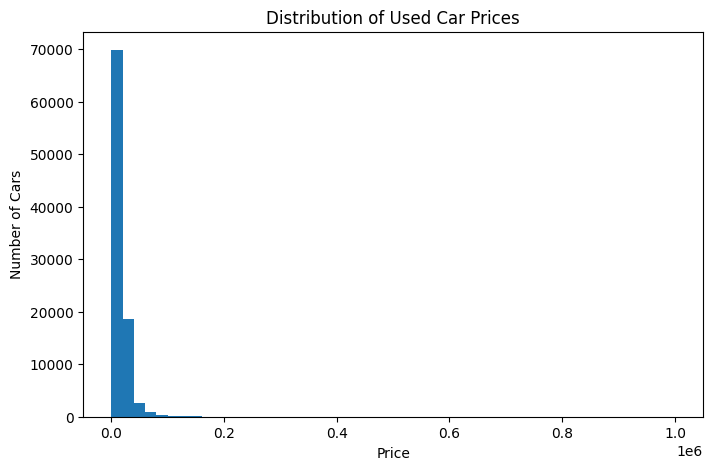

In [9]:
#histogram
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

Interpretation

Most used cars are in the lower price range. There are a few very expensive cars, which create a long right-side tail. This means the price distribution is right-skewed.

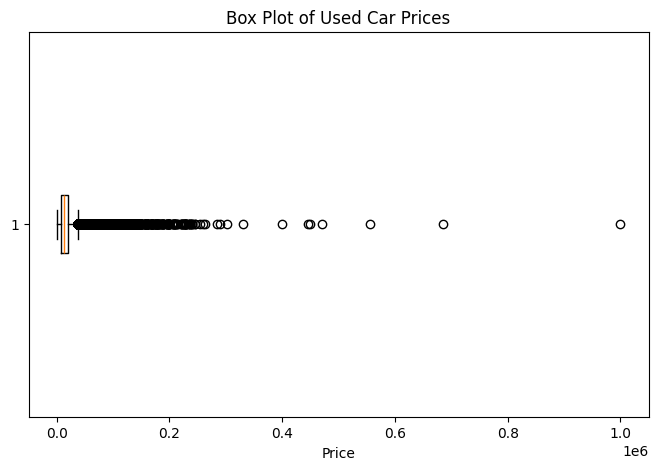

In [10]:
#box plot
plt.figure(figsize=(8,5))
plt.boxplot(df["price"], vert=False)
plt.title("Box Plot of Used Car Prices")
plt.xlabel("Price")
plt.show()

Interpretation

The box plot shows that there are many outliers in price. Some cars are much more expensive than normal used cars. These are probably luxury or sports cars.

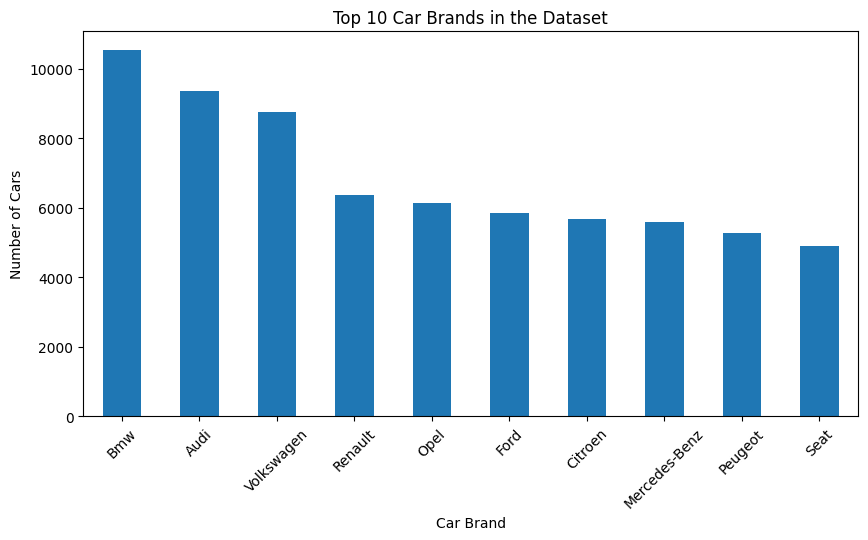

In [11]:
#Bar Chart
top_makes = df["make"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_makes.plot(kind="bar")
plt.title("Top 10 Car Brands in the Dataset")
plt.xlabel("Car Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.show()

Interpretation

The most common brands in the dataset are BMW, Audi, Volkswagen, Renault, Opel, and Ford

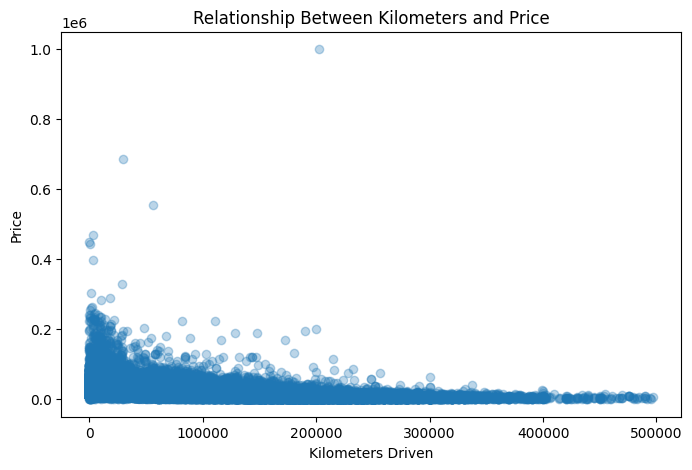

In [15]:
#scatter plot between kilometers and price
plt.figure(figsize=(8,5))
plt.scatter(df["kms"], df["price"], alpha=0.3)
plt.title("Relationship Between Kilometers and Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")
plt.show()

There is a negative relationship between kilometers and price. Cars with higher mileage usually have lower prices. This is expected because used cars lose value as they are driven more.

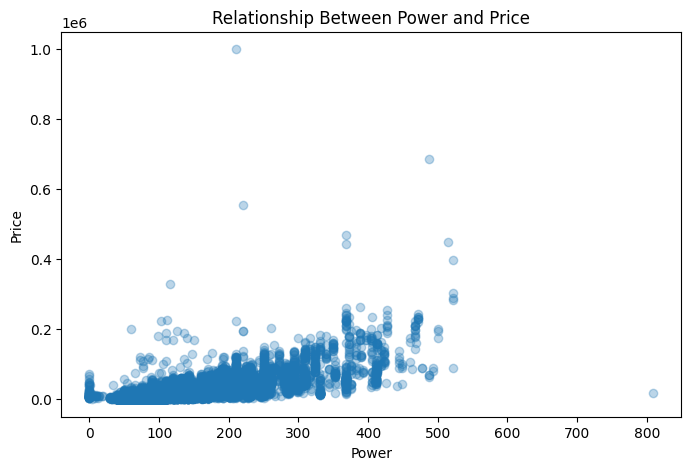

In [17]:
#Scatter plot between power and price
plt.figure(figsize=(8,5))
plt.scatter(df["power"], df["price"], alpha=0.3)
plt.title("Relationship Between Power and Price")
plt.xlabel("Power")
plt.ylabel("Price")
plt.show()

Interpretation

There is a positive relationship between power and price. Cars with more power usually have higher prices. This is because powerful cars are often higher-end models.

3. Regression Analysis for Price Prediction

● Build a simple linear regression model to predict car price.

● Clearly state the Independent and Dependent variables

● Interpret your results.

● Provide a brief explanation of how well the model predicts used car prices.


In [20]:
#correlation with price
df[["months_old", "power", "kms", "price", "age"]].corr()["price"].sort_values(ascending=False)

,price
price,1.000000
power,0.667184
age,0.341283
months_old,-0.344790
kms,-0.348508


Dependent variable: price
Independent variable: power

We choose power because it has the strongest relationship with price.

In [21]:
#regression
X = df[["power"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

Intercept: -8015.254629023271
Coefficient: 245.8729563306213
R2 Score: 0.4666266524116529
Mean Absolute Error: 6829.654688603102
Root Mean Squared Error: 10128.602184528421


Predicted Price = 245.87 × Power - 8015 (y=mx+c)
Simple interpretation

For every 1 unit increase in power, the predicted car price increases by about 245.87.

The R² value is around 0.467, which means power alone explains about 46.7% of the variation in used car prices.

This is a moderate model. It gives some useful prediction, but it is not perfect because car price also depends on many other factors such as brand, model, age, mileage, fuel type, and gear type.

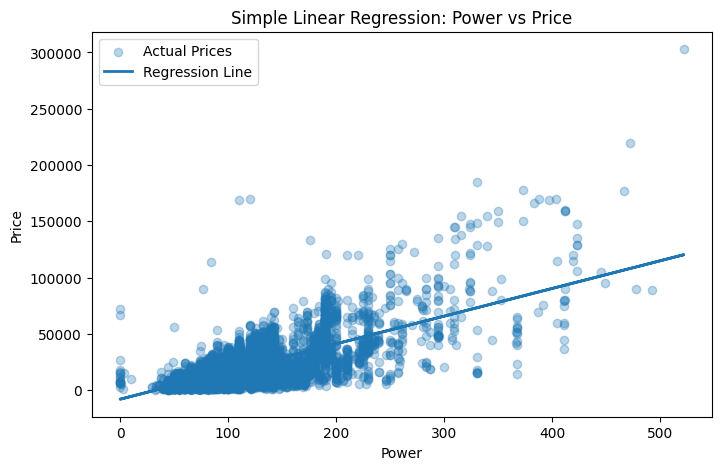

In [23]:
# plot regression line
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.3, label="Actual Prices")
plt.plot(X_test, y_pred, linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression: Power vs Price")
plt.xlabel("Power")
plt.ylabel("Price")
plt.legend()
plt.show()

Interpretation

The regression line shows a positive relationship between power and price. As power increases, the predicted price also increases. However, many points are spread around the line, meaning power alone cannot fully explain price.